# Computing Laplace–Beltrami Eigenfunctions from Signed Distance Fields

This notebook implements a variational framework for computing the eigenfunctions
of the Laplace–Beltrami operator (LBO) on surfaces defined implicitly, without mesh extraction.

**Pipeline overview:**
1. **Part I — Analytic Surface (Mushroom):** Validate the method on a parametric surface where exact normals and sampling are available.
2. **Part II — Implicit Surface (FAUST):** Apply the method to a human body shape represented by a learned neural SDF.

Each algorithmic step is accompanied by its mathematical formulation.

In [4]:
import math, os, sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import torch
import torch.nn as nn
import torch.optim as optim

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device = {device}')

device = cuda


## Scale invariance of the Rayleigh quotient (read before worrying about area)

The Rayleigh quotient

$$\mathcal{R}[\phi]=\frac{\int_\Sigma \lVert\nabla_\Sigma\phi\rVert^2\,dA}{\int_\Sigma \phi^2\,dA}$$

is **invariant under any global rescaling of the measure** $dA\to c\,dA$: the constant $c$ multiplies numerator and denominator equally and cancels. So:

* The Monte-Carlo prefactor $\mathrm{vol}(B)/(2\epsilon N)$ — and indeed the *total surface area* $A_\Sigma$ itself — **never affect the eigenvalue estimate.** Getting the absolute area "wrong" by a constant is harmless.
* What does **not** cancel is a **non-uniform reweighting** of the measure. If the samples have density $\rho(\mathbf{x})\neq\text{const}$ with respect to area, the unweighted ratio estimates the Rayleigh quotient of the *$\rho$-weighted* Laplacian, whose eigenvalues differ from the standard LBO.

For the thin-shell-rejection + Newton-projection sampler, projected points land on $\Sigma$ with density $\propto 1/\lVert\nabla F\rVert$. The per-sample weight $w_i=\lVert\nabla F(\mathbf{x}_i)\rVert$ is therefore **essential and exact** (it converts that density back to the uniform area measure), while the global area constant is irrelevant. Bottom line: a wrong *global* area cannot explain an eigenvalue discrepancy — only a wrong *weighting*, a different *surface*, or the comparison itself can.


In [5]:
# =====================================================================
# Shared utilities  --  used by BOTH Part I (Mushroom) and Part II (FAUST)
# All mass-weighted (M) linear algebra lives here so the two parts compare
# neural and cotangent bases in *exactly* the same way.
# =====================================================================
from scipy.spatial import cKDTree
from scipy.optimize import linear_sum_assignment


def to_numpy(x):
    return x.detach().cpu().numpy() if torch.is_tensor(x) else np.asarray(x)


# ---- mass-matrix helpers --------------------------------------------
# M may be a scipy sparse matrix OR a 1-D lumped-mass vector (Mdiag).
def _M_apply(M, X):
    """Return M @ X, whether M is sparse or a diagonal vector."""
    if sp.issparse(M):
        return M @ X
    M = np.asarray(M)
    return M[:, None] * X if X.ndim == 2 else M * X


def m_inner(a, b, M):
    """<a,b>_M = a^T M b.  Accepts vectors or [V,K] stacks."""
    return a.T @ _M_apply(M, b)


def m_inner_matrix(Phi, M):
    """Gram matrix  Phi^T M Phi  ->  [K,K]."""
    return Phi.T @ _M_apply(M, Phi)


def m_norm(a, M, eps=1e-12):
    return np.sqrt(np.maximum(m_inner(a, a, M), eps))


def m_normalize_columns(Phi, M, eps=1e-12):
    """Scale each column so phi_k^T M phi_k = 1.  Returns (Phi_normed, norms)."""
    norms = np.sqrt(np.maximum(np.diag(m_inner_matrix(Phi, M)), eps))
    return Phi / norms[None, :], norms


def remove_m_mean(Phi, M):
    """Project out the constant component under the M inner product."""
    Phi2 = Phi[:, None] if Phi.ndim == 1 else Phi
    ones = np.ones((Phi2.shape[0], 1))
    mean = m_inner(ones, Phi2, M) / m_inner(ones, ones, M)
    out = Phi2 - ones @ mean
    return out[:, 0] if Phi.ndim == 1 else out


def mesh_rq(phi, L, M, eps=1e-12):
    """Discrete Rayleigh quotient  phi^T L phi / phi^T M phi."""
    return float((phi.T @ (L @ phi)) / (m_inner(phi, phi, M) + eps))


# ---- evaluate trained neural eigenfunctions on a vertex set ---------
@torch.no_grad()
def eval_models_on_mesh(models, V_np, device, batch_size=65536):
    """Evaluate each model at the mesh vertices -> Phi [V, len(models)]."""
    V = torch.as_tensor(V_np, dtype=torch.float32, device=device)
    cols = []
    for m in models:
        m.eval()
        vals = []
        for s in range(0, V.shape[0], batch_size):
            y = m(V[s:s + batch_size])
            vals.append((y[:, 0] if y.ndim == 2 else y).cpu())
        cols.append(torch.cat(vals).numpy())
    return np.stack(cols, axis=1)


# ---- basis normalization / orthogonality diagnostic -----------------
def check_basis_normalization(Phi_raw, M, label='neural basis'):
    """Report raw M-norms and the Gram matrix of an (un-normalized) basis."""
    G = m_inner_matrix(Phi_raw, M)
    norms = np.sqrt(np.maximum(np.diag(G), 0.0))
    Phi_n, _ = m_normalize_columns(Phi_raw, M)
    Gn = m_inner_matrix(Phi_n, M)
    off = Gn - np.diag(np.diag(Gn))
    print(f'[{label}]  columns = {Phi_raw.shape[1]}')
    print(f'  raw M-norms        : {np.round(norms, 4)}')
    print(f'  Gram diag (normed) : {np.round(np.diag(Gn), 4)}')
    print(f'  max |off-diagonal| : {np.abs(off).max():.4e}')
    return G


def drop_near_constant(Phi, M, phi0_normed, thresh=0.9, verbose=True):
    """Remove neural columns that collapsed onto the constant mode.

    phi0_normed must be the M-normalized constant eigenfunction."""
    Phi_n, _ = m_normalize_columns(Phi, M)
    ov = np.abs(m_inner(Phi_n, phi0_normed, M)).ravel()
    mask = ov > thresh
    if verbose:
        print(f'  columns flagged ~constant (|<.,phi0>_M| > {thresh}): '
              f'{np.where(mask)[0].tolist()}  overlaps={np.round(ov[mask], 3).tolist()}')
    return Phi[:, ~mask], ~mask


# ---- degenerate-subspace (Procrustes) alignment ---------------------
def align_degenerate_pairs(Phi_nn, Phi_cot, evals, M, tol=0.5):
    """Rotate near-degenerate neural blocks onto the cotangent basis so that
    plots and per-mode overlaps are meaningful inside an eigenspace."""
    Phi_aligned = Phi_nn.copy()
    n, i = Phi_nn.shape[1], 0
    while i < n:
        j = i + 1
        while j < n and abs(evals[j] - evals[i]) < tol:
            j += 1
        if j - i > 1:
            C = m_inner(Phi_nn[:, i:j], Phi_cot[:, i:j], M)
            Uu, _, Vt = np.linalg.svd(C)
            Phi_aligned[:, i:j] = Phi_nn[:, i:j] @ (Uu @ Vt).T
        i = j
    return Phi_aligned


# ---- match a neural basis to the cotangent basis + report ----------
def compare_neural_to_cotangent(Phi_nn_raw, lam_nn, U_cot, lam_cot, M,
                                use_hungarian=True):
    """Bring a *non-constant* raw neural basis into correspondence with the
    *non-constant* cotangent basis (column k <-> mode k+1).

    Returns matched/normalized/sign-aligned neural basis, the permuted
    eigenvalues, the full |correlation| matrix, and per-mode overlaps.

    NOTE: lam_nn are passed through (permuted) unchanged -- decide *which*
    eigenvalue you report (training RQ vs mesh RQ) before calling this; see
    the eigenvalue-comparison discussion."""
    Phi_nn, _ = m_normalize_columns(Phi_nn_raw, M)
    U_cot, _  = m_normalize_columns(U_cot, M)
    K = min(Phi_nn.shape[1], U_cot.shape[1])
    Phi_nn, U_cot = Phi_nn[:, :K], U_cot[:, :K]
    lam_nn, lam_cot = np.asarray(lam_nn)[:K], np.asarray(lam_cot)[:K]
    IP = m_inner(Phi_nn, U_cot, M)                       # [K,K] cosines
    if use_hungarian:
        r, c = linear_sum_assignment(-np.abs(IP))
        perm = np.empty(K, dtype=int)
        perm[c] = r
        Phi_nn, lam_nn = Phi_nn[:, perm], lam_nn[perm]
        IP = m_inner(Phi_nn, U_cot, M)
    for i in range(K):                                   # sign flip
        if IP[i, i] < 0:
            Phi_nn[:, i] *= -1
    Phi_nn = align_degenerate_pairs(Phi_nn, U_cot, lam_cot, M)
    corr = np.abs(m_inner(Phi_nn, U_cot, M))
    return dict(Phi_nn=Phi_nn, U_cot=U_cot, lam_nn=lam_nn, lam_cot=lam_cot,
                corr=corr, overlaps=np.abs(np.diag(corr)))


def print_eigenvalue_table(lam_nn, lam_cot, overlaps):
    print('=' * 56)
    print('  k | neural lambda | cot lambda | overlap')
    print('----+---------------+------------+--------')
    for i in range(len(lam_nn)):
        ref = lam_cot[i]
        print(f'  {i+1} | {lam_nn[i]:13.4f} | {ref:10.4f} | {overlaps[i]:.4f}')


# ---- side-by-side mode plot with a SHARED color scale --------------
def plot_mode_on_mesh(ax, verts, faces, phi, title, vmax=None):
    """Single mode on a 3-D mesh.  If vmax is given the color scale is FIXED
    (pass the same vmax to two calls to make them directly comparable)."""
    if vmax is None:
        vmax = max(np.abs(phi).max(), 1e-12)
    fc = plt.cm.coolwarm(Normalize(-vmax, vmax)(phi[faces].mean(1)))
    ax.add_collection3d(Poly3DCollection(verts[faces], facecolors=fc,
                                         edgecolors='none'))
    lim = np.abs(verts).max() * 1.1
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
    ax.set_box_aspect([np.ptp(verts[:, i]) for i in range(3)])
    ax.view_init(20, 45); ax.axis('off')
    ax.set_title(title, fontsize=9)


def plot_mode_comparison(verts, faces, U_cot, lam_cot, Phi_nn, lam_nn,
                         overlaps=None, n_show=None, title=''):
    """Cotangent (top row) vs neural (bottom row).

    For each column k the SAME vmax = max(|cot_k|, |nn_k|) is used for both
    rows, so the neural and cotangent modes are drawn on one common color
    scale.  U_cot / Phi_nn must be the non-constant bases already in
    correspondence (column k <-> mode k+1)."""
    K = U_cot.shape[1] if n_show is None else min(n_show, U_cot.shape[1])
    fig = plt.figure(figsize=(3.5 * K, 7))
    for k in range(K):
        vmax = max(np.abs(U_cot[:, k]).max(),
                   np.abs(Phi_nn[:, k]).max(), 1e-12)        # shared scale
        ax = fig.add_subplot(2, K, k + 1, projection='3d')
        plot_mode_on_mesh(ax, verts, faces, U_cot[:, k],
                          f'cot phi_{k+1}  lam={lam_cot[k]:.3f}', vmax=vmax)
        ax = fig.add_subplot(2, K, K + k + 1, projection='3d')
        ov = '' if overlaps is None else f'\n|<.,.>_M|={overlaps[k]:.2f}'
        plot_mode_on_mesh(ax, verts, faces, Phi_nn[:, k],
                          f'nn phi_{k+1}  lam={lam_nn[k]:.3f}{ov}', vmax=vmax)
    if title:
        plt.suptitle(title, fontsize=12, y=1.02)
    plt.tight_layout(); plt.show()


---
# Part I — Analytic Parametric Surface Validation (Mushroom)

We first validate the entire pipeline on an analytic parametric surface where:
- Surface points can be sampled exactly (no SDF approximation)
- Normals are computed analytically via $\partial P/\partial U \times \partial P/\partial V$
- A ground-truth mesh can be constructed for cotangent-Laplacian comparison

This isolates the **algorithm** from SDF quality issues.

## 1.1 Surface Definition

The mushroom surface is defined in spherical polar coordinates $(U, V)$ with $U \in [0,\pi]$, $V \in [0,2\pi]$:

$$r_{\mathrm{mush}}(U,V) = 0.301\left(1 + 0.05\left(2U^3\sin^2(6U) + 0.6\,(U(\pi-U))^2\sin^2(6V+6U^2)\right)\right)$$

The Cartesian embedding is $P(U,V) = r_{\mathrm{mush}}(U,V) \cdot (\sin U \cos V,\; \sin U \sin V,\; \cos U)$.

In [6]:
def mushroom_surface(U, V):
    # Parametric mushroom surface. U in [0,pi], V in [0,2pi].
    r = 0.301 * (1 + 0.05 * (2 * U**3 * torch.sin(6*U)**2
                + 0.6 * (U * (math.pi - U))**2 * torch.sin(6*V + 6*U**2)**2))
    x = r * torch.sin(U) * torch.cos(V)
    y = r * torch.sin(U) * torch.sin(V)
    z = r * torch.cos(U)
    return x, y, z

## 1.2 Surface Sampling with Exact Normals

For a parametric surface $P(U,V): \mathbb{R}^2 \to \mathbb{R}^3$, the unit normal and area element are:

$$\mathbf{n} = \frac{\partial P/\partial U \times \partial P/\partial V}{\left|\partial P/\partial U \times \partial P/\partial V\right|}, \qquad dA = \left|\frac{\partial P}{\partial U} \times \frac{\partial P}{\partial V}\right| \, dU \, dV$$

We compute both via `autograd` and use **area-weighted resampling** to obtain approximately uniform samples on $\Sigma$.

In [7]:
def mushroom_normals_and_area(U, V):
    # Compute exact normals and area element via autograd on the parametric surface.
    U = U.detach().clone().requires_grad_(True)
    V = V.detach().clone().requires_grad_(True)
    x, y, z = mushroom_surface(U, V)

    # ∂P/∂U via autograd
    dxdU = torch.autograd.grad(x.sum(), U, create_graph=True)[0]
    dydU = torch.autograd.grad(y.sum(), U, create_graph=True)[0]
    dzdU = torch.autograd.grad(z.sum(), U, create_graph=True)[0]
    dPdU = torch.stack([dxdU, dydU, dzdU], dim=-1)

    # ∂P/∂V via autograd
    dxdV = torch.autograd.grad(x.sum(), V, create_graph=True)[0]
    dydV = torch.autograd.grad(y.sum(), V, create_graph=True)[0]
    dzdV = torch.autograd.grad(z.sum(), V, create_graph=True)[0]
    dPdV = torch.stack([dxdV, dydV, dzdV], dim=-1)

    # Normal = ∂P/∂U × ∂P/∂V,  area element = |normal|
    cross = torch.linalg.cross(dPdU, dPdV)
    area = cross.norm(dim=-1)
    normals = cross / (area.unsqueeze(-1) + 1e-12)
    return torch.stack([x, y, z], dim=-1).detach(), normals.detach(), area.detach()


def sample_mushroom(n_samples, device):
    # Area-weighted sampling on the mushroom surface.
    n_over = n_samples * 4
    U = torch.rand(n_over, device=device) * math.pi
    V = torch.rand(n_over, device=device) * 2 * math.pi
    pts, norms, area = mushroom_normals_and_area(U, V)
    # Importance resampling by area element
    probs = area / area.sum()
    idx = torch.multinomial(probs, n_samples, replacement=False)
    return pts[idx], norms[idx]

# Quick test
pts_test, n_test = sample_mushroom(2000, device)
print(f'Sample shape: {pts_test.shape}, |n| mean: {n_test.norm(dim=1).mean():.4f}')

Sample shape: torch.Size([2000, 3]), |n| mean: 1.0000


## 1.3 Ground Truth: Cotangent Laplacian on a Dense Mesh

We build a triangle mesh of the mushroom and compute the standard cotangent-Laplacian eigenpairs as reference.

In [10]:
def build_mushroom_mesh(n_U=200, n_V=200):
    # Build a triangle mesh of the mushroom for ground-truth comparison.
    u = np.linspace(1e-6, np.pi - 1e-6, n_U)
    v = np.linspace(0, 2*np.pi, n_V, endpoint=False)
    UU, VV = np.meshgrid(u, v, indexing='ij')

    r = 0.301 * (1 + 0.05 * (2*UU**3 * np.sin(6*UU)**2
                + 0.6 * (UU*(np.pi - UU))**2 * np.sin(6*VV + 6*UU**2)**2))
    x = r * np.sin(UU) * np.cos(VV)
    y = r * np.sin(UU) * np.sin(VV)
    z = r * np.cos(UU)

    verts = np.stack([x.ravel(), y.ravel(), z.ravel()], axis=1)
    faces = []
    for i in range(n_U - 1):
        for j in range(n_V):
            j1 = (j + 1) % n_V
            v00, v01 = i*n_V + j, i*n_V + j1
            v10, v11 = (i+1)*n_V + j, (i+1)*n_V + j1
            faces += [[v00, v10, v01], [v01, v10, v11]]
    return verts, np.array(faces, dtype=np.int64)


def cotangent_lbo(verts, faces, k=20):
    # Compute the first k eigenpairs of the cotangent Laplacian.
    import robust_laplacian
    L, M = robust_laplacian.mesh_laplacian(verts, faces)
    evals, evecs = spla.eigsh(L, k=k, M=M, sigma=1e-6, which='LM')
    order = np.argsort(evals)
    return evals[order], evecs[:, order], L, M


K = 7  # number of non-constant modes
mush_verts, mush_faces = build_mushroom_mesh(300, 300)
mush_evals, mush_evecs, L_mush, M_mush = cotangent_lbo(mush_verts, mush_faces, k=K+1)
Mdiag_mush = np.array(M_mush.sum(axis=1)).flatten()

print(f'Mesh: {mush_verts.shape[0]} verts, {mush_faces.shape[0]} faces')
print(f'Eigenvalues: {np.round(mush_evals, 4)}')

Mesh: 90000 verts, 179400 faces
Eigenvalues: [ 0.      1.105   3.9423  7.4402  7.4402 10.3657 12.3945 12.3945]


## 1.4 Neural Eigenfunction Architecture

Each eigenfunction is represented as an MLP with Fourier positional encoding:

$$\gamma(\mathbf{x}) = \bigl(\mathbf{x},\; \sin(2^0\pi\mathbf{x}),\; \cos(2^0\pi\mathbf{x}),\; \ldots,\; \sin(2^{L-1}\pi\mathbf{x}),\; \cos(2^{L-1}\pi\mathbf{x})\bigr) \in \mathbb{R}^{3(2L+1)}$$

$$\tilde\phi_k = \mathrm{MLP}_{\theta_k} \circ \gamma : \mathbb{R}^3 \to \mathbb{R}$$

In [9]:
class FourierMLP(nn.Module):
    def __init__(self, in_dim=3, hidden=256, num_freq=3):
        super().__init__()
        feat_dim = in_dim * (2 * num_freq + 1)
        self.num_freq = num_freq
        self.net = nn.Sequential(
            nn.Linear(feat_dim, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, 1)
        )

    def encode(self, x):
        feats = [x]
        for k in range(self.num_freq):
            freq = (2.0 ** k) * math.pi
            feats += [torch.sin(freq * x), torch.cos(freq * x)]
        return torch.cat(feats, dim=-1)

    def forward(self, x):
        return self.net(self.encode(x))

## 1.5 Surface Gradient and Normal Component

The **surface gradient** of a function $\tilde\phi:\mathbb{R}^3\to\mathbb{R}$ restricted to $\Sigma$ is the tangential projection of the ambient gradient:

$$\nabla_\Sigma \phi = P \nabla\tilde\phi = \nabla\tilde\phi - (\nabla\tilde\phi \cdot \mathbf{n})\,\mathbf{n}$$

where $P = I - \mathbf{n}\mathbf{n}^\top$ is the tangential projector (Definition 2.1 in the paper). This gives:

$$|\nabla_\Sigma \phi|^2 = |\nabla\tilde\phi|^2 - (\nabla\tilde\phi \cdot \mathbf{n})^2$$

We also return the **normal component** $\nabla\tilde\phi \cdot \mathbf{n}$, which is needed for the gauge-freedom regularizer (Section 1.8).

In [11]:
def compute_gradient_components(u, x, normals):
    # Compute surface gradient and normal component of an ambient neural field.
    # Returns: tangential (N, 3) surface gradient, normal_comp (N, 1)
    grad_u = torch.autograd.grad(
        outputs=u, inputs=x,
        grad_outputs=torch.ones_like(u),
        create_graph=True, retain_graph=True
    )[0]
    normal_comp = (grad_u * normals).sum(dim=1, keepdim=True)   # (N, 1)
    tangential = grad_u - normal_comp * normals                  # (N, 3)
    return tangential, normal_comp


def compute_tangential_gradient(u, x, normals):
    # Convenience wrapper returning only the tangential part.
    tang, _ = compute_gradient_components(u, x, normals)
    return tang

## 1.6 Rayleigh Quotient

By the Courant–Fischer–Weyl min-max principle (Theorem 3.1), the $k$-th eigenfunction minimizes the **Rayleigh quotient** over the orthogonal complement of all lower modes:

$$\mathcal{R}[\phi] = \frac{\displaystyle\int_\Sigma |\nabla_\Sigma \phi|^2 \, dA}{\displaystyle\int_\Sigma \phi^2 \, dA}$$

The eigenvalue is recovered as $\lambda_k = \mathcal{R}[\phi_k]$ when $\|\phi_k\|_{L^2(\Sigma)}=1$.

**Note:** There is no factor of $\frac{1}{2}$. This follows from Green's first identity on a closed manifold:

$$\int_\Sigma \phi_k(-\Delta_\Sigma \phi_k)\,dA = \int_\Sigma |\nabla_\Sigma \phi_k|^2\,dA \implies \lambda_k = \int_\Sigma |\nabla_\Sigma \phi_k|^2\,dA$$

**Monte Carlo estimator** (using $N$ surface samples):

$$\tilde{\mathcal{R}}[\phi_k] = \frac{\sum_{j=1}^N |P(\mathbf{x}_j)\nabla\phi_k(\mathbf{x}_j)|^2}{\sum_{j=1}^N \phi_k(\mathbf{x}_j)^2}$$

## 1.7 Gram–Schmidt Orthogonal Projection

To enforce mutual orthonormality $\langle \phi_i, \phi_j \rangle_{L^2(\Sigma)} = \delta_{ij}$, we apply a differentiable Gram–Schmidt projection following Chang et al. (Shape Space Spectra, 2025).

Given previously computed (and frozen) eigenfunctions $\boldsymbol{\phi} = (\phi_0, \ldots, \phi_{k-1})$ and the current candidate $\tilde\phi_k$:

**Orthogonalize:** Compute coefficients $c_j = \langle \tilde\phi_k, \phi_j \rangle_{L^2(\Sigma)}$ and subtract:
$$\phi_k^\perp = \tilde\phi_k - \sum_{j=0}^{k-1} c_j \, \phi_j$$


**Gradient causal filtering:** We `detach()` the dominating modes $\phi_0,\ldots,\phi_{k-1}$ during backpropagation so that the orthogonality constraint only updates $\tilde\phi_k$, not the already-converged modes.

## 1.8 Training: Joint Optimization with Causal Sorting

We train all $K$ eigenfunctions jointly. At each epoch:
1. **Causal sorting:** Sort modes by current Rayleigh quotient (ascending) to determine the Gram–Schmidt order.
2. **Gram–Schmidt projection:** In sorted order, project each mode orthogonal to all dominating modes.
3. **Loss:** $\mathcal{L} = \sum_{k=1}^K \bigl[\tilde{\mathcal{R}}[\phi_k] + \mu \cdot \tilde{\mathcal{R}}_{\mathbf{n}}[\phi_k]\bigr]$

In [8]:
K = 7
NUM_EPOCHS = 15000
BATCH_SIZE = 4096
LEARNING_RATE = 2e-3
ORTHO_PENALTY = 50.0
#MU_NORMAL = 0.1
PRINT_EVERY = 500

models = [FourierMLP(num_freq=4).to(device) for _ in range(K)]
optimizers = [optim.AdamW(m.parameters(), lr=LEARNING_RATE) for m in models]
schedulers = [optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS, eta_min=1e-4)
              for opt in optimizers]
rq_history = [[] for _ in range(K)]

for epoch in range(NUM_EPOCHS):
    # ── Sample from analytic surface ──
    x_pts, normals = sample_mushroom(BATCH_SIZE, device)
    x = x_pts.detach().clone().requires_grad_(True)
    N = x.shape[0]

    # ── Step 1: Causal sorting by current Rayleigh quotient ──
    energies = []
    for idx in range(K):
        x_eval = x.detach().clone().requires_grad_(True)
        raw = models[idx](x_eval)
        df = compute_tangential_gradient(raw, x_eval, normals)
        with torch.no_grad():
            energy = (df.detach()**2).sum() / ((raw.detach()**2).sum() + 1e-12)
        energies.append(energy.item())
    _, indices = torch.sort(torch.tensor(energies))

    # ── Step 2: Train in sorted order with Gram-Schmidt ──
    phi0 = torch.ones(N, 1, device=device)
    U_prev = phi0
    G_prev = torch.zeros(N, 1, 3, device=device)

    for j in range(K):
        idx = indices[j].item()
        x_train = x.detach().clone().requires_grad_(True)
        raw = models[idx](x_train)
        df, normal_comp = compute_gradient_components(raw, x_train, normals)

        # Gram-Schmidt projection
        U_prev_d = U_prev.detach()
        UT = U_prev_d.T
        q = torch.linalg.lstsq(UT @ U_prev_d, UT @ raw).solution
        reconstruct = U_prev_d @ q
        outputs_proj = raw - reconstruct

        G_prev_d = G_prev.detach()
        reconstruct_grad = torch.einsum('njd,jk->nd', G_prev_d, q)
        df_proj = df - reconstruct_grad

        # Loss: Rayleigh quotient + orthogonality penalty
        denom = (outputs_proj ** 2).sum() + 1e-12
        rq = (df_proj ** 2).sum() / denom
        ortho_pen = (reconstruct ** 2).sum() / denom

        loss = rq + ORTHO_PENALTY * ortho_pen

        optimizers[idx].zero_grad()
        loss.backward(retain_graph=True)
        optimizers[idx].step()
        rq_history[idx].append(rq.item())

        U_prev = torch.cat([U_prev, outputs_proj.detach()], dim=1)
        G_prev = torch.cat([G_prev, df_proj.detach().unsqueeze(1)], dim=1)

    for s in schedulers:
        s.step()

    if (epoch + 1) % PRINT_EVERY == 0 or epoch == 0:
        sorted_rqs = [rq_history[indices[j].item()][-1] for j in range(K)]
        print(f'epoch {epoch+1:5d} | sorted RQ = {np.round(sorted_rqs, 4)}')
        print(f'           | ref evals = {np.round(mush_evals[1:K+1], 4)}')

print('\nTraining complete.')

epoch     1 | sorted RQ = [104.9356 194.4503  91.291  135.5674 236.664  173.4675 240.9691]
           | ref evals = [ 1.105   3.9423  7.4402  7.4402 10.3657 12.3945 12.3945]
epoch   500 | sorted RQ = [ 1.5853  6.2645  9.4963  9.7317 15.464  19.9239 29.4062]
           | ref evals = [ 1.105   3.9423  7.4402  7.4402 10.3657 12.3945 12.3945]
epoch  1000 | sorted RQ = [ 1.3219  4.5717  8.4543  8.7797 13.2851 14.1856 15.1273]
           | ref evals = [ 1.105   3.9423  7.4402  7.4402 10.3657 12.3945 12.3945]
epoch  1500 | sorted RQ = [ 1.3144  4.5651  8.3109  8.445  10.9588 13.8754 14.3967]
           | ref evals = [ 1.105   3.9423  7.4402  7.4402 10.3657 12.3945 12.3945]
epoch  2000 | sorted RQ = [ 1.2212  4.2483  8.0195  8.2283 10.5668 13.4708 14.0326]
           | ref evals = [ 1.105   3.9423  7.4402  7.4402 10.3657 12.3945 12.3945]
epoch  2500 | sorted RQ = [ 1.2448  4.1478  8.0039  8.2189 10.194  12.9732 13.8559]
           | ref evals = [ 1.105   3.9423  7.4402  7.4402 10.3657 12.3945 

## 1.10 Evaluation

We evaluate the trained neural eigenfunctions on the mesh vertices, apply mass-weighted Gram–Schmidt orthogonalization, and compare against the cotangent-Laplacian ground truth.

**Metrics:**
- **Eigenvalue relative error:** $|\lambda_k^{\mathrm{nn}} - \lambda_k^{\mathrm{cot}}| / \lambda_k^{\mathrm{cot}}$
- **Subspace overlap:** $|\langle \phi_k^{\mathrm{nn}}, \phi_k^{\mathrm{cot}} \rangle_M|$ (should be $\approx 1$ if the mode is correctly learned)

In [9]:
# ── Causal order of the trained mushroom models ──
def compute_final_energies(models, device, n_samples=20000):
    x_pts, normals = sample_mushroom(n_samples, device)
    x = x_pts.detach().clone().requires_grad_(True)
    energies = []
    for m in models:
        m.eval()
        x_eval = x.detach().clone().requires_grad_(True)
        raw = m(x_eval)
        df = compute_tangential_gradient(raw, x_eval, normals)
        with torch.no_grad():
            energies.append((df.detach()**2).sum().item()
                             / ((raw.detach()**2).sum().item() + 1e-12))
    return np.array(energies)

final_energies = compute_final_energies(models, device)
causal_order = np.argsort(final_energies)
print(f'Causal order: {causal_order.tolist()}')
print(f'Sorted energies: {np.round(final_energies[causal_order], 4)}')

# ── Evaluate neural eigenfunctions on the mesh (incl. constant phi_0) ──
Phi_nn_raw = np.concatenate(
    [np.ones((mush_verts.shape[0], 1)),
     eval_models_on_mesh([models[i] for i in causal_order], mush_verts, device)],
    axis=1)

# ── Eigenvalues: mesh Rayleigh quotient of the RAW neural functions ──
# (RQ is computed BEFORE any orthogonalization -- orthogonalizing mixes
#  modes and changes the quotient.)
lam_nn_full = np.array([mesh_rq(Phi_nn_raw[:, i], L_mush, M_mush)
                        for i in range(Phi_nn_raw.shape[1])])

# ── Normalization / orthogonality check of the learned basis ──
check_basis_normalization(Phi_nn_raw[:, 1:], M_mush, 'mushroom neural basis')

# ── Match non-constant neural modes to the cotangent modes ──
res = compare_neural_to_cotangent(
    Phi_nn_raw[:, 1:], lam_nn_full[1:],
    mush_evecs[:, 1:K + 1], mush_evals[1:K + 1], M_mush)

print_eigenvalue_table(res['lam_nn'], res['lam_cot'], res['overlaps'])


Causal order: [4, 3, 0, 5, 6, 1, 2]
Sorted energies: [ 1.061   3.9892  7.8687  7.9634 10.2307 13.0328 13.1957]
[mushroom neural basis]  columns = 7
  raw M-norms        : [4.2569 2.4402 3.6295 2.0985 2.7741 5.2939 1.7273]
  Gram diag (normed) : [1. 1. 1. 1. 1. 1. 1.]   (target: all 1)
  max |off-diagonal| : 8.2814e-02        (target: 0)
  k | neural lambda | cot lambda | rel_err | overlap
----+---------------+------------+---------+--------
  1 |        1.1506 |     1.1050 |    4.1% | 0.9986
  2 |        4.1276 |     3.9423 |    4.7% | 0.9942
  3 |        7.6361 |     7.4402 |    2.6% | 0.3084
  4 |        7.6509 |     7.4402 |    2.8% | 0.3086
  5 |       10.5875 |    10.3657 |    2.1% | 0.9908
  6 |       12.7561 |    12.3945 |    2.9% | 0.5230
  7 |       12.6748 |    12.3945 |    2.3% | 0.5229


## 1.11 Visualization

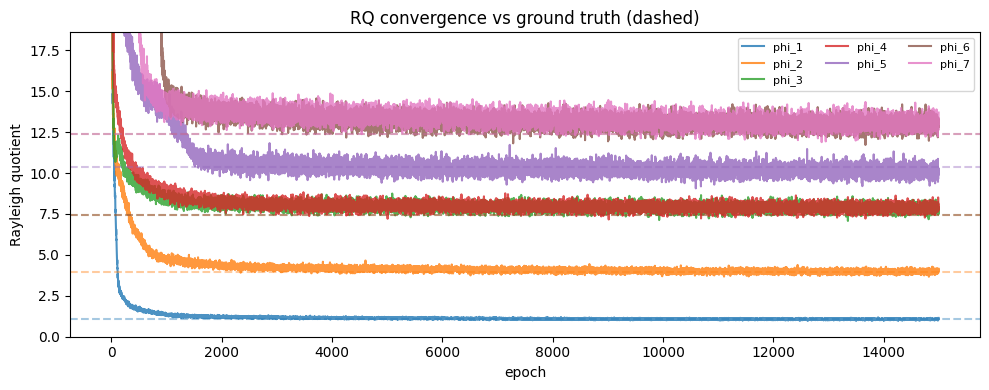

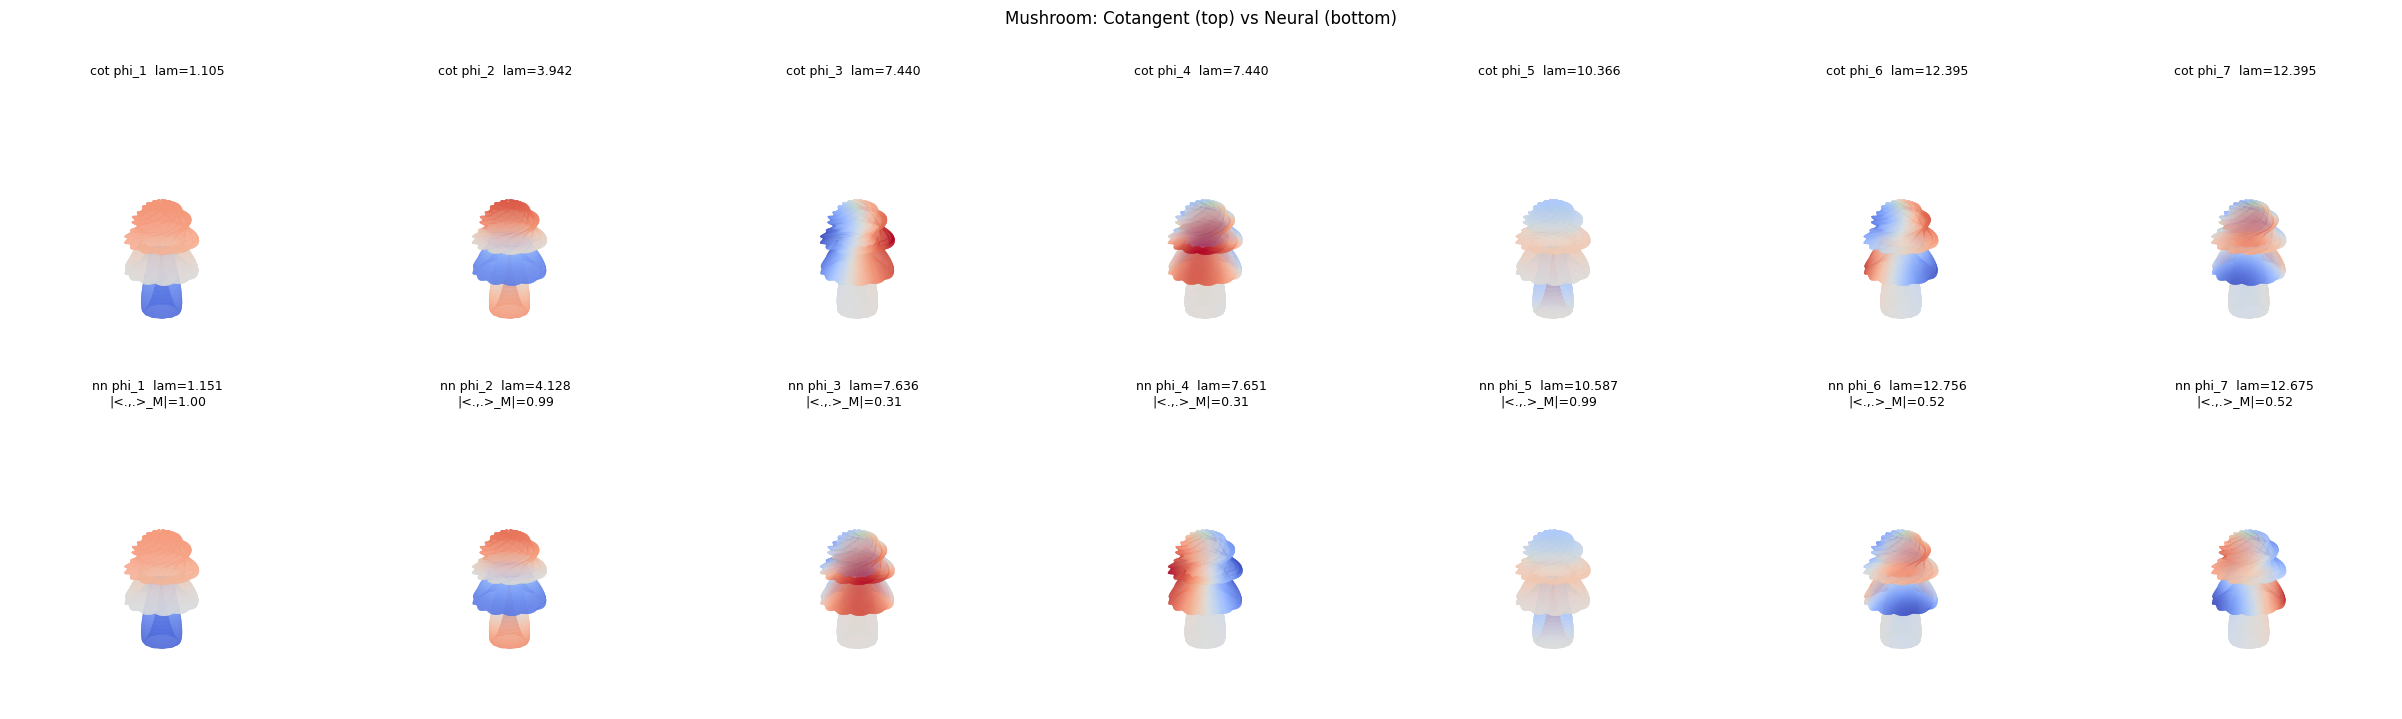

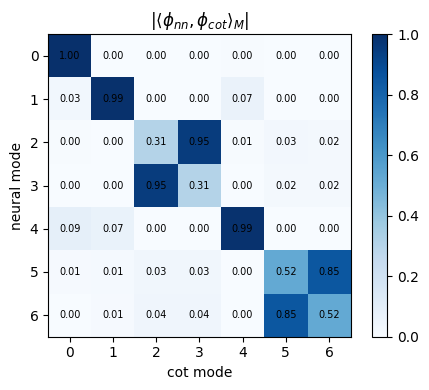

In [10]:
# ── Convergence plot ──
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
for j in range(K):
    idx = causal_order[j]
    ax.plot(rq_history[idx], alpha=0.8, label=f'phi_{j+1}')
    ax.axhline(mush_evals[j + 1], color=f'C{j}', ls='--', alpha=0.4)
ax.set_xlabel('epoch'); ax.set_ylabel('Rayleigh quotient')
ax.set_title('RQ convergence vs ground truth (dashed)')
ax.legend(ncol=3, fontsize=8)
ax.set_ylim(0, mush_evals[min(K, len(mush_evals) - 1)] * 1.5)
plt.tight_layout(); plt.show()

# ── Side-by-side eigenfunction comparison (SHARED color scale per mode) ──
plot_mode_comparison(mush_verts, mush_faces,
                     res['U_cot'], res['lam_cot'],
                     res['Phi_nn'], res['lam_nn'],
                     overlaps=res['overlaps'],
                     title='Mushroom: Cotangent (top) vs Neural (bottom)')

# ── Overlap matrix ──
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(res['corr'], cmap='Blues', vmin=0, vmax=1)
ax.set_xlabel('cot mode'); ax.set_ylabel('neural mode')
ax.set_title(r'$|\langle \phi_{nn}, \phi_{cot}\rangle_M|$')
for i in range(res['corr'].shape[0]):
    for j in range(res['corr'].shape[1]):
        ax.text(j, i, f"{res['corr'][i, j]:.2f}", ha='center', va='center', fontsize=7)
plt.colorbar(im); plt.tight_layout(); plt.show()


---
# Part II — Implicit Surface (FAUST Human Body)

We now apply the same pipeline to a surface defined only through a signed distance field (SDF), without access to a parametric form. The key difference is how surface integrals are computed.

## The Coarea Formula

For an analytic surface (Part I), we computed $\int_\Sigma g\,dA$ directly via the parametric area element $|\partial_U P \times \partial_V P|\,dU\,dV$. For an implicit surface $\Sigma = \{f(\mathbf{x})=0\}$, no such parametrization exists. The **coarea formula** provides the bridge:

$$\int_\Sigma g(\mathbf{x})\,dA = \int_{\mathbb{R}^3} g(\mathbf{x})\,\delta\bigl(f(\mathbf{x})\bigr)\,|\nabla f(\mathbf{x})|\,dV$$

**Mollified approximation** (narrow-band indicator $\delta_\epsilon(t) = \frac{1}{2\epsilon}\mathbf{1}_{|t|<\epsilon}$):

$$\int_\Sigma g\,dA \;\approx\; \frac{1}{2\epsilon}\int_{\{|f(\mathbf{x})|<\epsilon\}} g(\mathbf{x})\,|\nabla f(\mathbf{x})|\,dV$$

**Monte Carlo estimator** (sample $\{\mathbf{x}_j\}$ uniformly in bounding box, reject $|f(\mathbf{x}_j)| \geq \epsilon$):

$$\int_\Sigma g\,dA \;\approx\; \frac{\mathrm{vol}(B)}{|\mathcal{X}|} \cdot \frac{1}{2\epsilon} \sum_{\mathbf{x}_j \in \mathcal{X}} g(\mathbf{x}_j)\,|\nabla f(\mathbf{x}_j)|$$

The prefactor $\mathrm{vol}(B)/(2\epsilon)$ cancels in the Rayleigh quotient (it appears in both numerator and denominator).

## 2.1 Load the Trained DiGS SDF Model

In [14]:
# ─── CONFIG: set these paths ───
DIGS_SCRIPT_DIR = '/home/jxiao/Downloads/neural-surface/'
CHECKPOINT_PATH = '/home/jxiao/Downloads/neural-surface/digs_output_1/model_epoch_5.pth'
FAUST_MESH_PATH = '/home/jxiao/Downloads/neural-surface/FAUST_r/off/tr_reg_000.off'

HIDDEN_DIM = 256
N_LAYERS = 4
NL = 'sine'
INIT_TYPE = 'mfgi'
SPHERE_INIT_PARAMS = [1.6, 0.1]

In [16]:
import torch
from train_igr_faust import IGRNetwork

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

CHECKPOINT_PATH = "/home/jxiao/Downloads/neural-surface/shape000/igr_model.pth"

ckpt = torch.load(CHECKPOINT_PATH, map_location=device,weights_only=False)

sdf_model = IGRNetwork(**ckpt["arch"]).to(device)
sdf_model.load_state_dict(ckpt["state_dict"])
sdf_model.eval()

cp = ckpt["cp"]
scale = ckpt["scale"]

print("loaded model")
print("cp:", cp)
print("scale:", scale)

# Wrap as a simple function
def sdf_torch(x):
    out = sdf_model(x)
    return out[:, 0] if out.dim() == 2 else out

loaded model
cp: [ 3.17649765e-17 -1.85277767e-17 -2.88188268e-17]
scale: 0.6828715667748244


In [12]:
# ── Import and load model ──
sys.path.insert(0, DIGS_SCRIPT_DIR)
from train_faust import DiGSNetwork

sdf_model = DiGSNetwork(
    in_dim=3,
    decoder_hidden_dim=HIDDEN_DIM,
    decoder_n_hidden_layers=N_LAYERS,
    nl=NL,
    init_type=INIT_TYPE,
    sphere_init_params=SPHERE_INIT_PARAMS,
).to(device)

state_dict = torch.load(CHECKPOINT_PATH, map_location=device)
sdf_model.load_state_dict(state_dict)
sdf_model.eval()
print(f'Loaded DiGS checkpoint from {CHECKPOINT_PATH}')
print(f'Parameters: {sum(p.numel() for p in sdf_model.parameters()):,}')

# Wrap as a simple function
def sdf_torch(x):
    out = sdf_model.decoder(x)
    return out[:, 0] if out.dim() == 2 else out

Loaded DiGS checkpoint from /home/jxiao/Downloads/neural-surface/digs_output_1/model_epoch_5.pth
Parameters: 264,449


## 2.2 SDF Quality Diagnostics

Before training eigenfunctions, we verify that the SDF is well-trained. Key metrics:
- $\mathbb{E}[|f(\mathbf{x})|]$ on mesh vertices should be $< 0.001$
- $\mathbb{E}[|\nabla f|]$ should be $\approx 1.0$ (Eikonal property)
- $\mathrm{std}(|\nabla f|)$ should be $< 0.05$

In [17]:
import trimesh

# Load mesh and normalize to SDF coordinate system
mesh = trimesh.load(FAUST_MESH_PATH, process=False)
V_orig = np.array(mesh.vertices)
cp = V_orig.mean(0)
scale = np.abs(V_orig - cp).max()
V_norm = (V_orig - cp) / scale

# Diagnostics
x_diag = torch.from_numpy(V_norm).float().to(device)
x_diag.requires_grad_(True)
f_diag = sdf_torch(x_diag)
g_diag = torch.autograd.grad(f_diag.sum(), x_diag)[0]

with torch.no_grad():
    print(f"mean |f| on mesh verts:  {f_diag.abs().mean():.4f}   (target: < 0.001)")
    print(f"max  |f| on mesh verts:  {f_diag.abs().max():.4f}")
    print(f"mean |∇f| on mesh verts: {g_diag.norm(dim=1).mean():.4f}  (target: ≈ 1.0)")
    print(f"std  |∇f| on mesh verts: {g_diag.norm(dim=1).std():.4f}   (target: < 0.05)")

mean |f| on mesh verts:  0.0005   (target: < 0.001)
max  |f| on mesh verts:  0.0027
mean |∇f| on mesh verts: 0.9834  (target: ≈ 1.0)
std  |∇f| on mesh verts: 0.0468   (target: < 0.05)


## 2.3 Ground Truth: Cotangent Laplacian on the FAUST Mesh

In [18]:
import robust_laplacian

K_faust = 12
F_mesh = np.array(mesh.faces)
L_faust, M_faust = robust_laplacian.mesh_laplacian(V_norm, F_mesh)
Mdiag_faust = np.array(M_faust.sum(axis=1)).flatten()
evals_faust, evecs_faust = spla.eigsh(L_faust, k=K_faust+1, M=M_faust, sigma=1e-6, which='LM')
order = np.argsort(evals_faust)
evals_faust = evals_faust[order]
evecs_faust = evecs_faust[:, order]
print(f'First {K_faust+1} eigenvalues: {np.round(evals_faust, 4)}')

First 13 eigenvalues: [-0.      2.0112  2.5933  3.8884  5.7607  8.1493 16.2792 16.544  23.6796
 24.9211 35.995  41.2841 48.1966]


## 2.4 Sampling Surface Points from the SDF

Since we have no parametric access to $\Sigma$, we sample via:
1. Uniform random points in a bounding box $B$
2. Reject points with $|f(\mathbf{x})| \geq \epsilon$ (narrow-band filter)
3. Project surviving points to $\Sigma$: $\hat{\mathbf{x}} = \mathbf{x} - f(\mathbf{x})\nabla f(\mathbf{x})$
4. Outlier removal via $k$-NN distance filtering

In [19]:
BBOX = 1.05

def sample_surface_from_sdf(n_samples=4096, band=0.01, bbox=BBOX, oversample=12, device=device):
    # Sample points on the zero level set of the learned SDF.
    batches = []
    total = 0
    while total < n_samples:
        cand = (torch.rand(n_samples * oversample, 3, device=device) * 2.0 - 1.0) * bbox
        cand.requires_grad_(True)
        sdf_vals = sdf_torch(cand)
        grad_sdf = torch.autograd.grad(sdf_vals.sum(), cand, create_graph=False)[0]
        mask = sdf_vals.abs() < band
        if mask.sum() == 0:
            continue
        x = cand[mask]
        s = sdf_vals[mask].unsqueeze(-1)
        g = grad_sdf[mask]
        x_proj = x - s * g / (g.pow(2).sum(dim=1, keepdim=True) + 1e-12)
        batches.append(x_proj.detach())
        total += x_proj.shape[0]
    pts = torch.cat(batches, dim=0)

    # k-NN outlier removal
    from scipy.spatial import cKDTree
    dists = cKDTree(pts.cpu().numpy()).query(pts.cpu().numpy(), k=20)[0][:, 1:]
    keep = dists.mean(1) < dists.mean(1).mean() + 2 * dists.mean(1).std()
    pts = pts[keep]
    return pts[:n_samples]


def sdf_normals(x):
    # Compute unit normals = normalized SDF gradient.
    x = x.detach().clone().requires_grad_(True)
    sdf_vals = sdf_torch(x)
    g = torch.autograd.grad(sdf_vals.sum(), x, create_graph=False)[0]
    return (g / (g.norm(dim=1, keepdim=True) + 1e-12)).detach()

# Test
surface_pts = sample_surface_from_sdf(n_samples=4096)
print(f'Surface samples: {surface_pts.shape}')
with torch.no_grad():
    test_sdf = sdf_torch(surface_pts)
print(f'Mean |SDF(surface_pts)| = {test_sdf.abs().mean().item():.6f}')

Surface samples: torch.Size([4020, 3])
Mean |SDF(surface_pts)| = 0.000073


## 2.5 Build the Weighted Surface Pool

In [20]:
# Weighted surface pool: (point, normal, |grad F| weight) triples on the
# SDF zero level set.  Thin-shell rejection + Newton projection samples Gamma
# with density proportional to 1/||grad F||; the cached weight w_i = ||grad F||
# converts that back to the uniform area measure (see scale-invariance note).
BBOX = 1.05

def build_surface_pool(n_total=400_000, chunk=4096, band=0.01,
                       bbox=BBOX, oversample=12, device=device):
    pool_pts, pool_normals, pool_weights = [], [], []
    n_have = 0
    while n_have < n_total:
        cand = (torch.rand(chunk * oversample, 3, device=device) * 2.0 - 1.0) * bbox
        cand.requires_grad_(True)
        s = sdf_torch(cand)
        g = torch.autograd.grad(s.sum(), cand, create_graph=False)[0]
        mask = s.abs() < band
        if mask.sum() == 0:
            del cand, s, g
            continue
        x  = cand[mask].detach()
        sv = s[mask].detach().unsqueeze(-1)
        gv = g[mask].detach()
        x_proj = x - sv * gv / (gv.pow(2).sum(dim=1, keepdim=True) + 1e-12)

        # re-evaluate grad AT the projected point: accurate normal + weight
        xp = x_proj.clone().requires_grad_(True)
        sp = sdf_torch(xp)
        gp = torch.autograd.grad(sp.sum(), xp, create_graph=False)[0]
        gn = gp.norm(dim=1, keepdim=True)
        np_ = gp / (gn + 1e-12)

        pool_pts.append(x_proj.detach())
        pool_normals.append(np_.detach())
        pool_weights.append(gn.detach().squeeze(-1))
        n_have += x_proj.shape[0]
        del cand, s, g, x, sv, gv, x_proj, xp, sp, gp, gn, np_
        if device.type == 'cuda':
            torch.cuda.empty_cache()

    pts = torch.cat(pool_pts, dim=0)[:n_total]
    nrm = torch.cat(pool_normals, dim=0)[:n_total]
    wts = torch.cat(pool_weights, dim=0)[:n_total]

    # Mild kNN outlier removal (generous: do not preferentially discard
    # high-||grad F|| / high-weight regions).
    pts_np = pts.cpu().numpy()
    d = cKDTree(pts_np).query(pts_np, k=20)[0][:, 1:].mean(1)
    keep = torch.from_numpy(d < d.mean() + 4 * d.std()).to(device)
    pts, nrm, wts = pts[keep], nrm[keep], wts[keep]

    print(f'Pool built: {pts.shape[0]} pts | '
          f'w mean={wts.mean():.4f} std={wts.std():.4f} '
          f'min={wts.min():.4f} max={wts.max():.4f}')
    return pts, nrm, wts


def sample_from_pool(pool_pts, pool_normals, pool_weights, batch_size):
    idx = torch.randint(0, pool_pts.shape[0], (batch_size,), device=pool_pts.device)
    return pool_pts[idx], pool_normals[idx], pool_weights[idx]


POOL_SIZE = 400_000
pool_pts, pool_normals, pool_weights = build_surface_pool(n_total=POOL_SIZE)


Pool built: 399722 pts | w mean=0.9989 std=0.0268 min=0.0982 max=2.0259


## 2.6 Training Neural Eigenfunctions on the FAUST SDF

In [21]:
# Weighted training: the area-measure weights w_i = ||grad F|| make every
# inner product / Rayleigh quotient an estimate w.r.t. the TRUE area measure
# on Gamma.  (The global constant in those weights cancels in the RQ -- only
# the per-sample variation matters.)
K_train = 10
NUM_EPOCHS_FAUST = 15000
BATCH_SIZE_FAUST = 4096
LR_FAUST = 2e-3
ORTHO_PENALTY_FAUST = 100.0
PRINT_EVERY_FAUST = 500

models_f = [FourierMLP(num_freq=5).to(device) for _ in range(K_train)]
optimizers_f = [optim.AdamW(m.parameters(), lr=LR_FAUST) for m in models_f]
schedulers_f = [optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS_FAUST,
                                                     eta_min=1e-4)
                for opt in optimizers_f]
rq_history_f    = [[] for _ in range(K_train)]
ortho_history_f = [[] for _ in range(K_train)]

for epoch in range(NUM_EPOCHS_FAUST):
    x, normals, w = sample_from_pool(pool_pts, pool_normals, pool_weights,
                                     BATCH_SIZE_FAUST)
    x = x.detach().clone().requires_grad_(True)
    N = x.shape[0]

    # Normalize weights to sum to N (a pure constant rescale -> cancels in
    # the RQ; only keeps ORTHO_PENALTY on a stable scale).
    w = w * (N / (w.sum() + 1e-12))
    w_col = w.unsqueeze(-1)

    # ---- Causal sorting by current weighted Rayleigh quotient ----
    energies = []
    for idx in range(K_train):
        x_eval = x.detach().clone().requires_grad_(True)
        raw = models_f[idx](x_eval)
        df = compute_tangential_gradient(raw, x_eval, normals)
        with torch.no_grad():
            num = (w_col * df.detach()**2).sum()
            den = (w_col * raw.detach()**2).sum() + 1e-12
            energies.append((num / den).item())
    _, indices = torch.sort(torch.tensor(energies))

    # ---- Weighted Gram-Schmidt + training ----
    phi0 = torch.ones(N, 1, device=device)
    U_prev = phi0
    G_prev = torch.zeros(N, 1, 3, device=device)

    for j in range(K_train):
        idx = indices[j].item()
        x_train = x.detach().clone().requires_grad_(True)
        raw = models_f[idx](x_train)
        df, normal_comp = compute_gradient_components(raw, x_train, normals)

        # Weighted least squares onto span(U_prev): solve (U^T W U) q = U^T W raw
        U_prev_d = U_prev.detach()
        WU   = w_col * U_prev_d
        Gram = U_prev_d.T @ WU
        rhs  = WU.T @ raw
        q = torch.linalg.lstsq(Gram, rhs).solution
        reconstruct = U_prev_d @ q
        outputs_proj = raw - reconstruct

        # Same coefficients q for the tangential gradient (keeps autograd
        # path through the projection correct -- no detached basis grads).
        G_prev_d = G_prev.detach()
        reconstruct_grad = torch.einsum('njd,jk->nd', G_prev_d, q)
        df_proj = df - reconstruct_grad

        denom     = (w_col * outputs_proj**2).sum() + 1e-12
        rq        = (w_col * df_proj**2).sum() / denom
        ortho_pen = (w_col * reconstruct**2).sum() / denom
        loss = rq + ORTHO_PENALTY_FAUST * ortho_pen

        optimizers_f[idx].zero_grad()
        loss.backward()
        optimizers_f[idx].step()
        rq_history_f[idx].append(rq.item())
        ortho_history_f[idx].append(ortho_pen.item())

        U_prev = torch.cat([U_prev, outputs_proj.detach()], dim=1)
        G_prev = torch.cat([G_prev, df_proj.detach().unsqueeze(1)], dim=1)

    for s in schedulers_f:
        s.step()

    if (epoch + 1) % PRINT_EVERY_FAUST == 0 or epoch == 0:
        sorted_idx = [indices[j].item() for j in range(K_train)]
        sorted_rqs = [rq_history_f[i][-1] for i in sorted_idx]
        print(f'epoch {epoch+1:5d} | sorted RQ = {np.round(sorted_rqs, 4)}')
        print(f'             | ref evals = {np.round(evals_faust[1:K_train+1], 4)}')

print('\nFAUST training complete.')


epoch     1 | sorted RQ = [ 276.2708  438.6219  458.7967  883.1718  673.2386  510.8995  622.7223
  412.3388  836.016  1121.4949]
             | ref evals = [ 2.0112  2.5933  3.8884  5.7607  8.1493 16.2792 16.544  23.6796 24.9211
 35.995 ]
epoch   500 | sorted RQ = [ 2.9532  4.6119  6.8403  8.8462  9.9052 18.3066 27.7439 30.3563 35.365
 55.9437]
             | ref evals = [ 2.0112  2.5933  3.8884  5.7607  8.1493 16.2792 16.544  23.6796 24.9211
 35.995 ]
epoch  1000 | sorted RQ = [ 2.6913  3.0806  5.2357  6.8493  8.4446 15.4476 16.5643 25.9839 27.4389
 54.4232]
             | ref evals = [ 2.0112  2.5933  3.8884  5.7607  8.1493 16.2792 16.544  23.6796 24.9211
 35.995 ]
epoch  1500 | sorted RQ = [ 2.3373  2.8203  4.515   6.3883  8.5732 17.3209 17.3709 26.0793 27.4408
 41.2614]
             | ref evals = [ 2.0112  2.5933  3.8884  5.7607  8.1493 16.2792 16.544  23.6796 24.9211
 35.995 ]
epoch  2000 | sorted RQ = [ 2.401   3.0242  4.7122  6.5686  8.6084 17.165  17.3182 24.5252 26.8878
 38.80

## 2.7 FAUST Evaluation

In [ ]:
# ── Evaluate neural eigenfunctions on the FAUST mesh vertices ──
Phi_nn_raw = eval_models_on_mesh(models_f, V_norm, device)   # [V, K_train]
print('Phi_nn_raw shape:', Phi_nn_raw.shape)

# ── Normalization / orthogonality check of the learned basis ──
check_basis_normalization(Phi_nn_raw, M_faust, 'FAUST neural basis')

# ── Drop any neural column that collapsed onto the constant mode ──
phi0_cot = m_normalize_columns(evecs_faust[:, :1], M_faust)[0][:, 0]
Phi_nn_nc, keep_mask = drop_near_constant(Phi_nn_raw, M_faust, phi0_cot, thresh=0.9)

# ── Eigenvalues: mesh Rayleigh quotient of the RAW (non-constant) basis ──
lam_nn_mesh = np.array([mesh_rq(Phi_nn_nc[:, i], L_faust, M_faust)
                        for i in range(Phi_nn_nc.shape[1])])

# ── Match to the non-constant cotangent basis + report ──
K_nc = min(Phi_nn_nc.shape[1], evecs_faust.shape[1] - 1)
res_f = compare_neural_to_cotangent(
    Phi_nn_nc[:, :K_nc], lam_nn_mesh[:K_nc],
    evecs_faust[:, 1:K_nc + 1], evals_faust[1:K_nc + 1], M_faust)

print('\nlambda^{nn,mesh}  (neural functions measured by the mesh operator):')
print_eigenvalue_table(res_f['lam_nn'], res_f['lam_cot'], res_f['overlaps'])


Phi_nn_raw shape: (4999, 10)
[FAUST neural basis]  columns = 10
  raw M-norms        : [2.8042 2.958  2.6408 2.043  2.0628 4.317  2.8082 2.6116 4.406  1.9031]
  Gram diag (normed) : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  max |off-diagonal| : 2.2962e-02
  columns flagged ~constant (|<.,phi0>_M| > 0.9): []  overlaps=[]

lambda^{nn,mesh}  (neural functions measured by the mesh operator):
  k | neural lambda | cot lambda | overlap
----+---------------+------------+--------
  1 |        2.0729 |     2.0112 | 0.9995
  2 |        2.6043 |     2.5933 | 0.9999
  3 |        4.2405 |     3.8884 | 0.9990
  4 |        6.0689 |     5.7607 | 0.9985
  5 |        8.1913 |     8.1493 | 0.9995
  6 |       16.3239 |    16.2792 | 0.9349
  7 |       16.6081 |    16.5440 | 0.9349
  8 |       24.7469 |    23.6796 | 0.9984
  9 |       25.5738 |    24.9211 | 0.9975
  10 |       38.5789 |    35.9950 | 0.9972


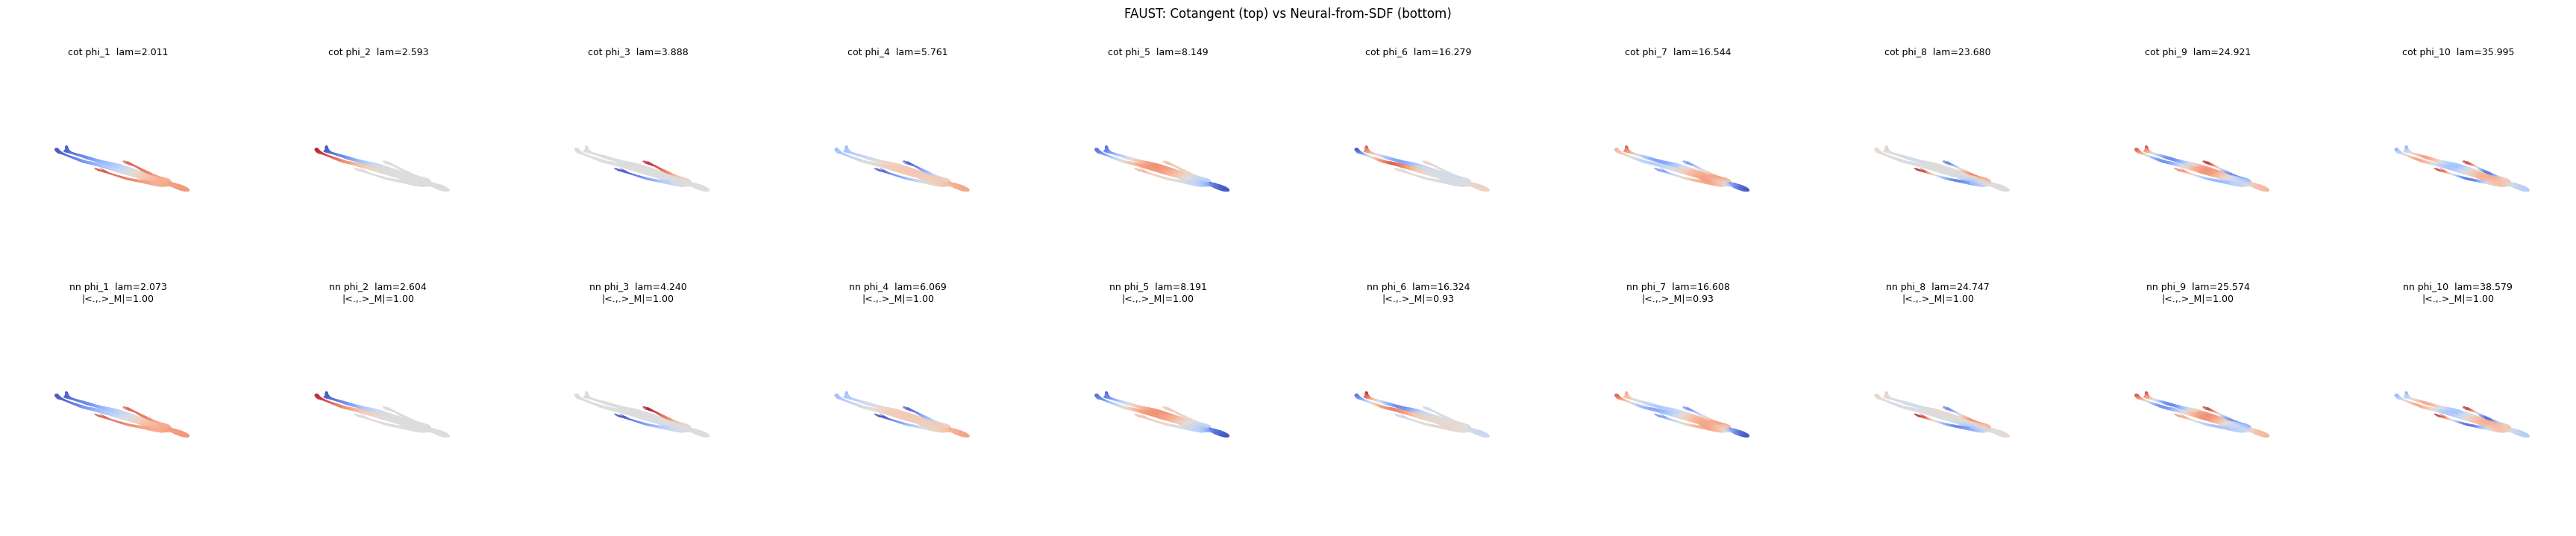

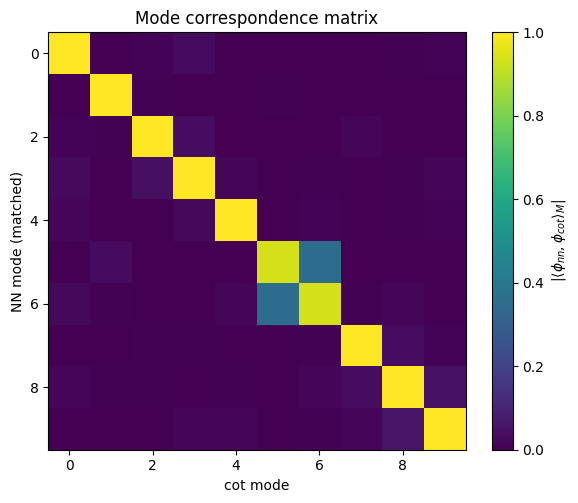

In [34]:
# ── Side-by-side comparison (SHARED color scale per mode) ──
plot_mode_comparison(V_norm, F_mesh,
                     res_f['U_cot'], res_f['lam_cot'],
                     res_f['Phi_nn'], res_f['lam_nn'],
                     overlaps=res_f['overlaps'],
                     title='FAUST: Cotangent (top) vs Neural-from-SDF (bottom)')

# ── Mode correspondence matrix (should be near-block-diagonal) ──
plt.figure(figsize=(6, 5))
plt.imshow(res_f['corr'], cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label=r'$|\langle \phi_{nn},\phi_{cot}\rangle_M|$')
plt.xlabel('cot mode'); plt.ylabel('NN mode (matched)')
plt.title('Mode correspondence matrix')
plt.tight_layout(); plt.show()
